# Label-Channel Bias All Model All Domain Comparison
This notebook generates plots for comparing models to determine if each one displays label channel bias on high positive case across all domains and models.
Load data by running `data_processing.ipynb` first.

## Setup

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
os.chdir("../..")

## Lookup Maps and Style Constants

In [3]:
rewards_per_scale = {
    'high_scale':     [75, 50, 25],
    'low_scale':      [0.75, 0.5, 0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale':  [-0.25, -0.5, -0.75],
}

STYLE_CONSTANTS = {
    'max_val': {
        'linestyle': '--',
        'color': 'black',
        'label': 'Maximum',
    },
    'min_val': {
        'linestyle': '--',
        'color': 'firebrick',
        'label': 'Minimum',
    },
}

NOM_STYLE_CONSTANTS = {
    'alphanumeric':     {'color': 'black',      'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful':  {'color': 'steelblue',  'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead':  {'color': 'steelblue',  'linestyle': '--', 'marker': 'x', 'label': 'Ordinal - Misleading'},
    'world_helpful':    {'color': 'darkgreen',  'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':    {'color': 'darkgreen',  'linestyle': '--', 'marker': 'x', 'label': 'World - Misleading'},
    'sent_new_helpful': {'color': 'darkorchid', 'linestyle': '-',  'marker': 'o', 'label': 'Sentiment - Helpful'},
    'sent_new_mislead': {'color': 'darkorchid', 'linestyle': '--', 'marker': 'x', 'label': 'Sentiment - Misleading'},
}

nom_legend_order = [
    'alphanumeric',
    'ordinal_helpful', 'ordinal_mislead',
    'world_helpful',   'world_mislead',
    'sent_new_helpful', 'sent_new_mislead',
]

nomenclature_map = {
    'alphanumeric':     'Alphanumeric',
    'ordinal_helpful':  'Ordinal - Helpful',
    'ordinal_mislead':  'Ordinal - Misleading',
    'world_helpful':    'World - Helpful',
    'world_mislead':    'World - Misleading',
    'sent_new_helpful': 'Sentiment - Helpful',
    'sent_new_mislead': 'Sentiment - Misleading',
}

metric_map = {
    'cum_regret':        'Scaled Cum. Regret',
    'exploration_count': 'States Explored',
}

## Configuration

In [4]:
# Load merged results from data_processing.ipynb output
results_df = pd.read_csv('experiments/merged_sem_var_results.csv')
print(f"Loaded {len(results_df)} rows")
results_df[['domain', 'model', 'history', 'variance']].value_counts().reset_index(name='count')

Loaded 1282 rows


,domain,model,history,variance,count
0,Farm,Qwen3-14B,Summarized,Low,36
1,Farm,Llama3-8B,Summarized,No,36
2,Farm,Qwen3-32B,Summarized,No,36
3,Farm,Qwen3-32B,Summarized,Low,36
4,Farm,Qwen3-32B,Summarized,High,36
5,Farm,Llama3-8B,Summarized,High,36
6,Farm,Qwen3-14B,Summarized,No,36
7,Farm,Llama3-8B,Summarized,Low,36
8,Farm,Qwen3-14B,Summarized,High,36
9,Clothing Recommendation,Llama3-8B,Summarized,No,29


In [7]:
# Metrics to plot
metrics = ['cum_regret', 'exploration_count']

# Scale to focus on
SCALE = 'high_scale'

# Nomenclatures to compare within each subplot
nomenclatures = [
    # 'alphanumeric',
    'ordinal_helpful', 'ordinal_mislead',
    'world_helpful',   'world_mislead',
    # 'sent_new_helpful', 'sent_new_mislead',
]

# Preferred domain column order (any not in this list are appended at the end)
domain_order = ['Farm', 'Bandit', 'Clothing Recommendation']

# Variance conditions to generate separate figures for
all_variances = ['No', 'Low', 'High']

# History filter
hist = 'Summarized'

## Plotting

One figure per model × metric × variance. Each figure has one subplot per domain (columns).
Each subplot shows one line per nomenclature, all for the `high_scale` (positive high) condition.

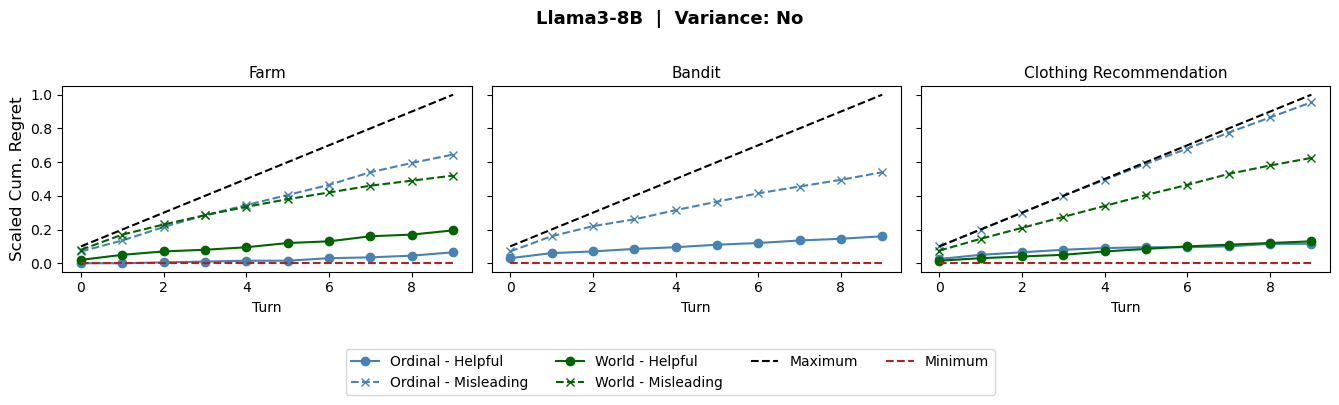

Saved: model=Llama3-8B, metric=cum_regret, variance=No


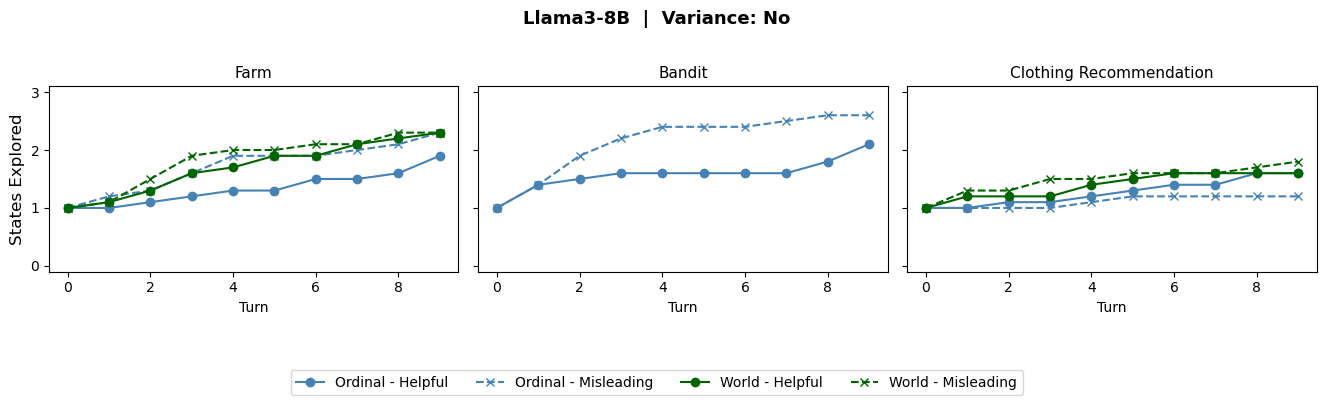

Saved: model=Llama3-8B, metric=exploration_count, variance=No


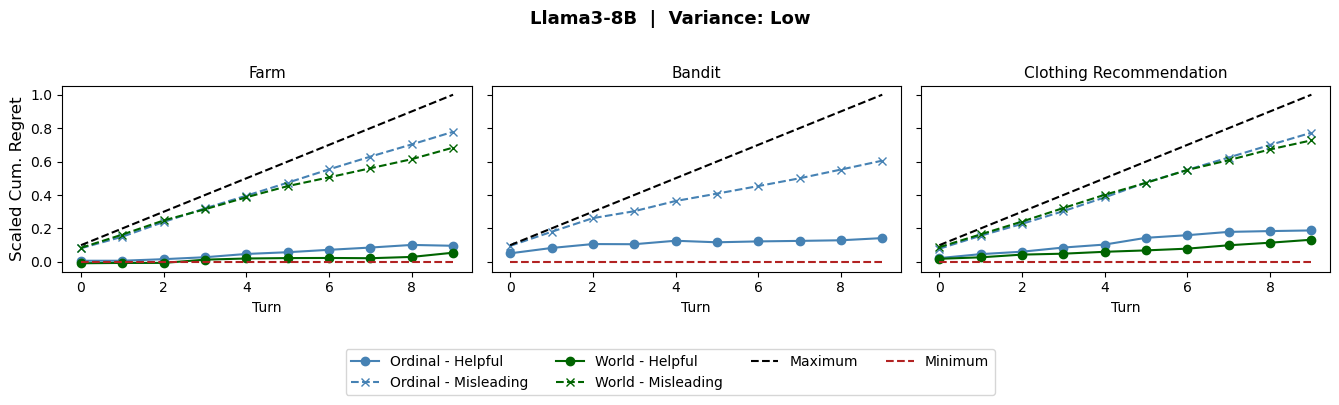

Saved: model=Llama3-8B, metric=cum_regret, variance=Low


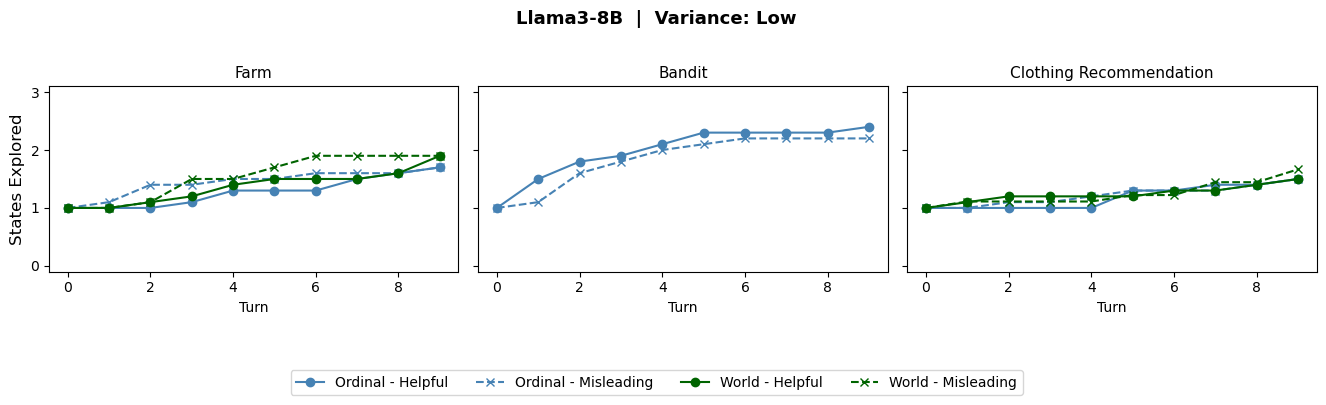

Saved: model=Llama3-8B, metric=exploration_count, variance=Low


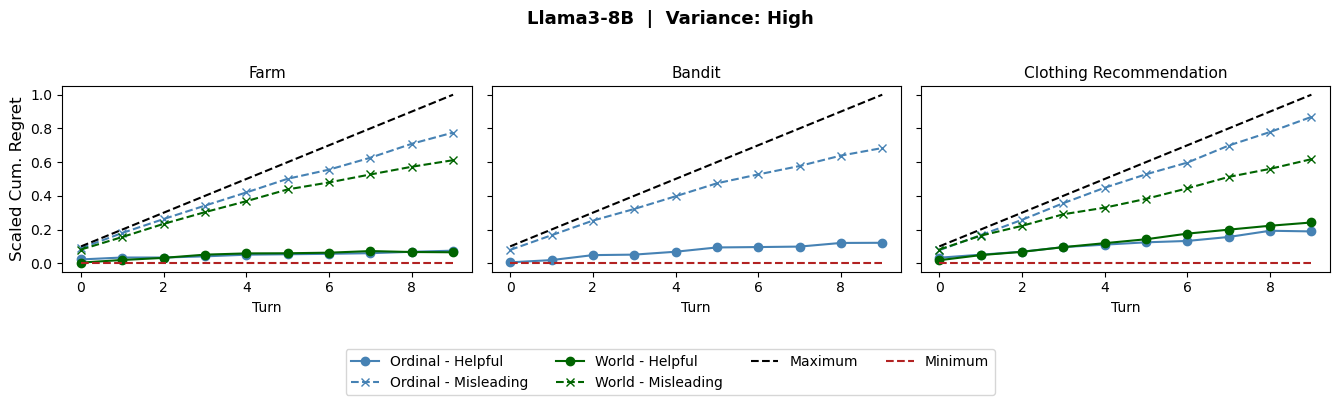

Saved: model=Llama3-8B, metric=cum_regret, variance=High


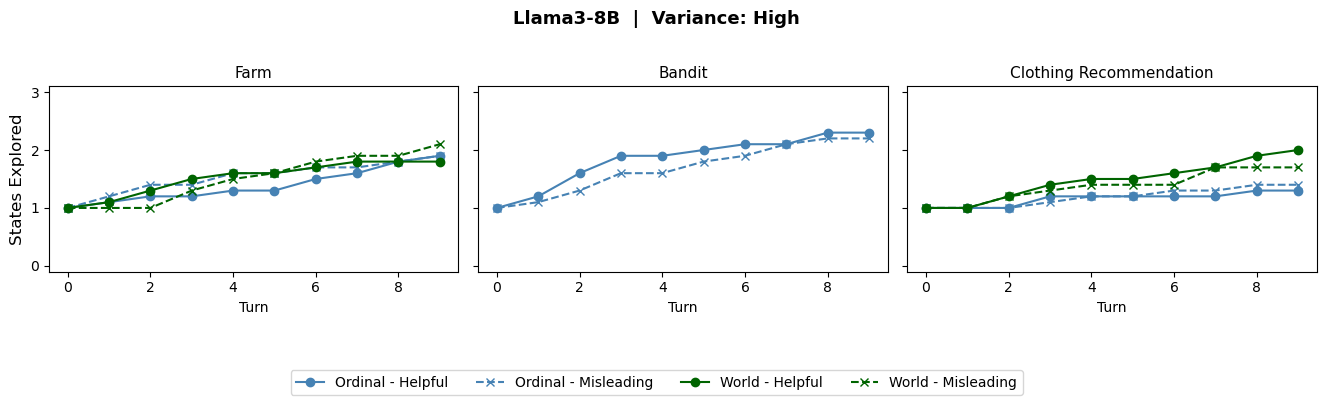

Saved: model=Llama3-8B, metric=exploration_count, variance=High


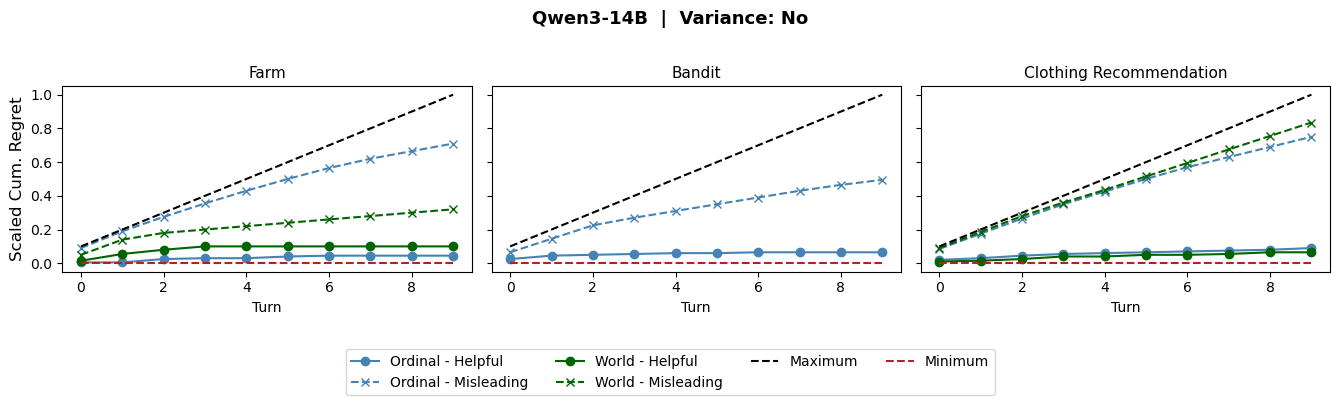

Saved: model=Qwen3-14B, metric=cum_regret, variance=No


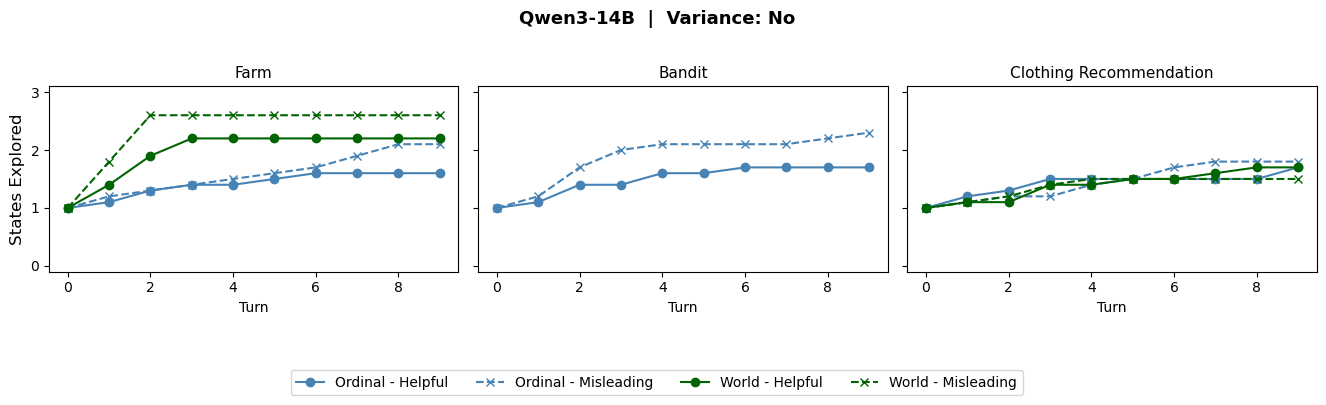

Saved: model=Qwen3-14B, metric=exploration_count, variance=No


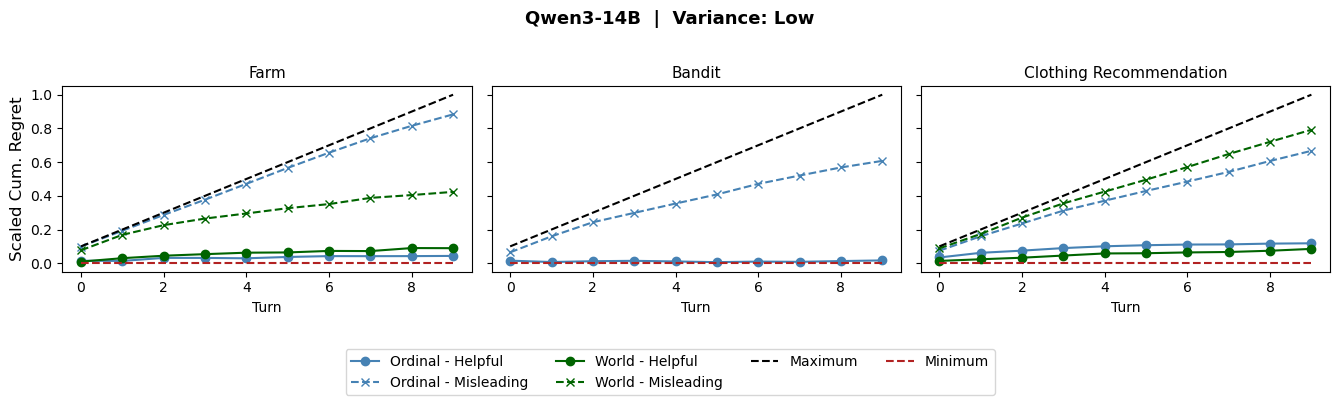

Saved: model=Qwen3-14B, metric=cum_regret, variance=Low


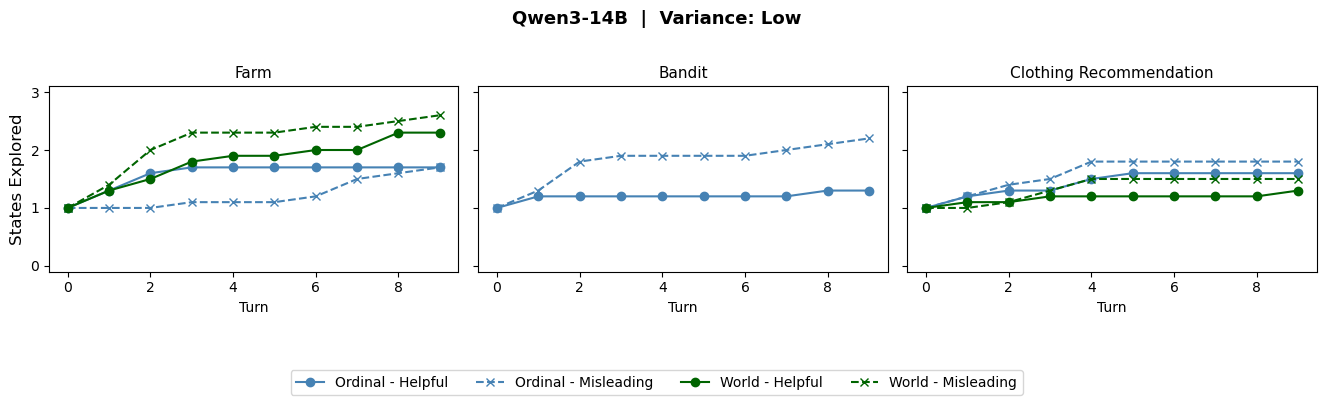

Saved: model=Qwen3-14B, metric=exploration_count, variance=Low


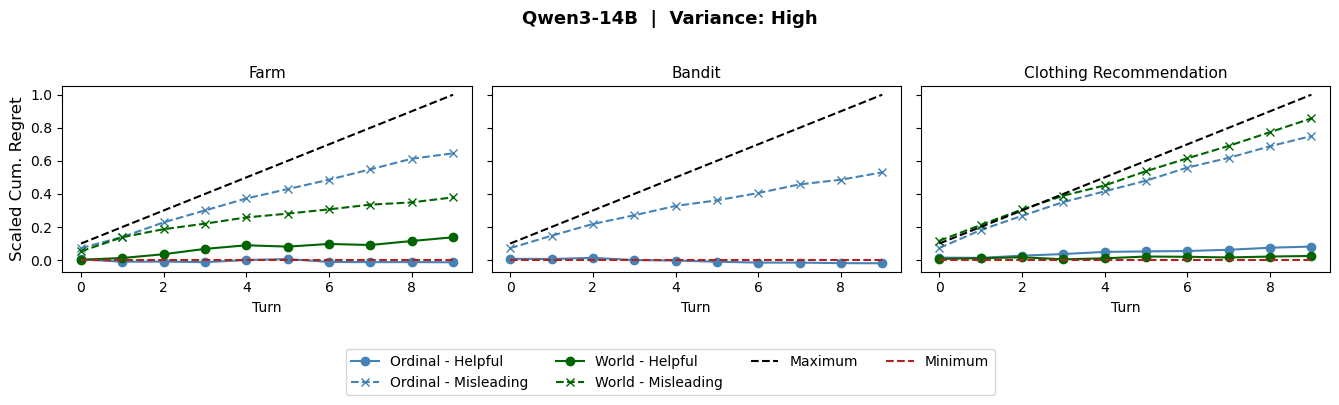

Saved: model=Qwen3-14B, metric=cum_regret, variance=High


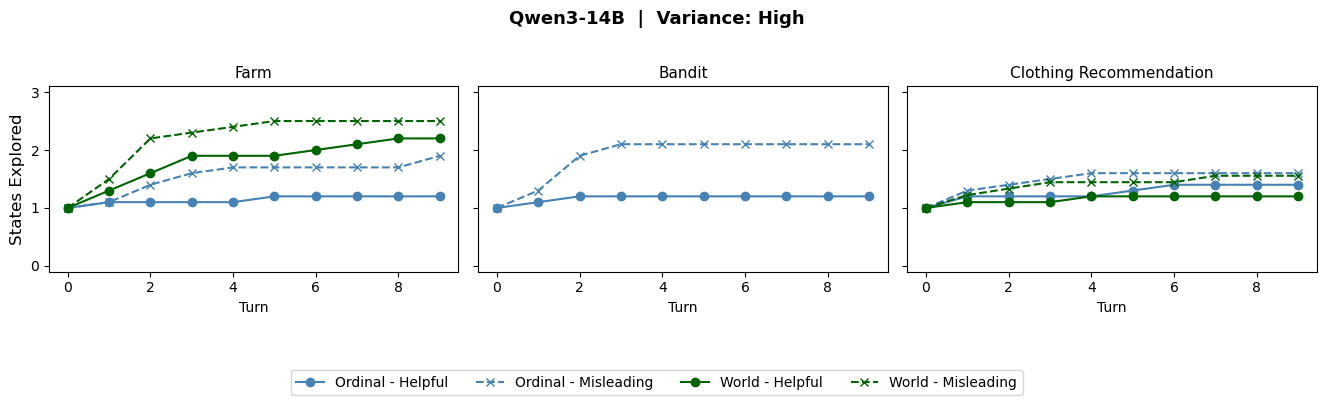

Saved: model=Qwen3-14B, metric=exploration_count, variance=High


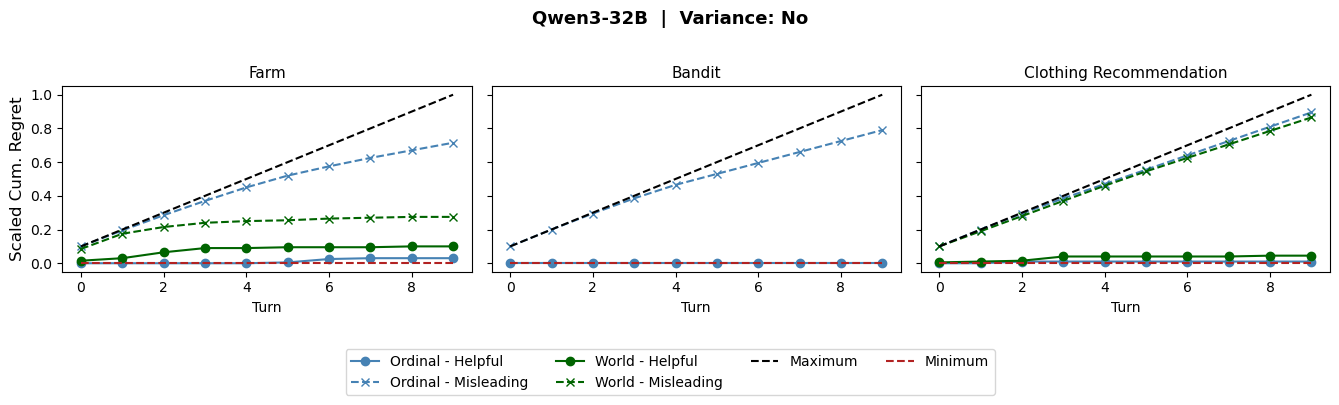

Saved: model=Qwen3-32B, metric=cum_regret, variance=No


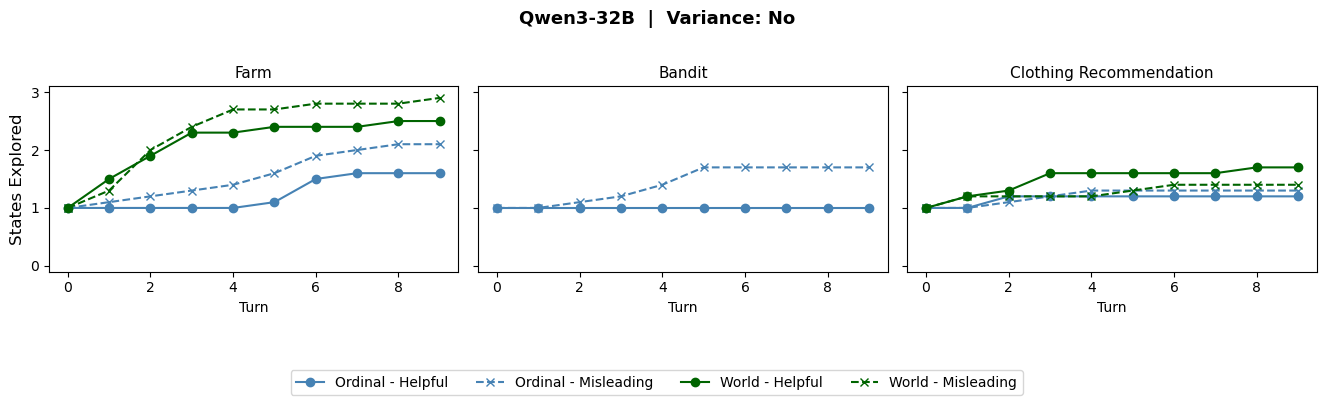

Saved: model=Qwen3-32B, metric=exploration_count, variance=No


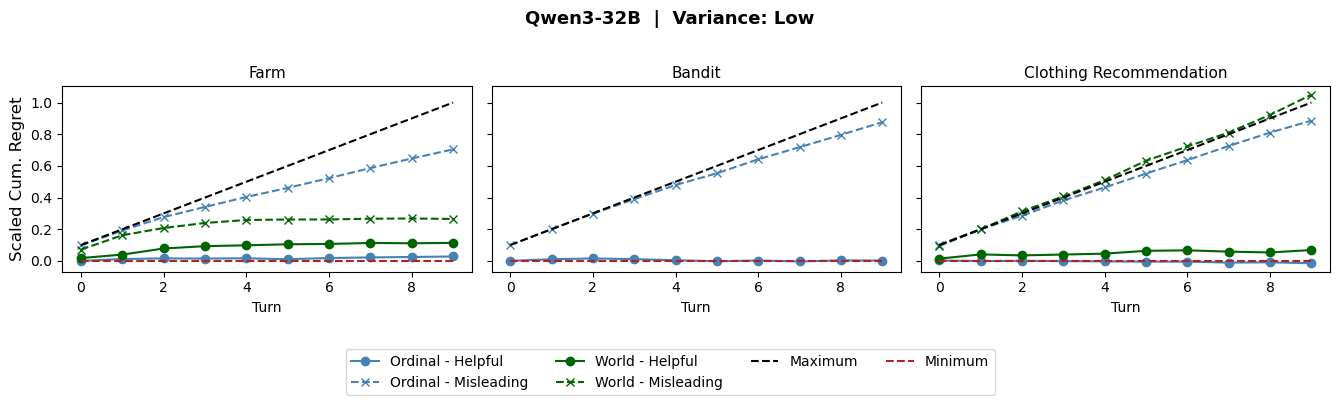

Saved: model=Qwen3-32B, metric=cum_regret, variance=Low


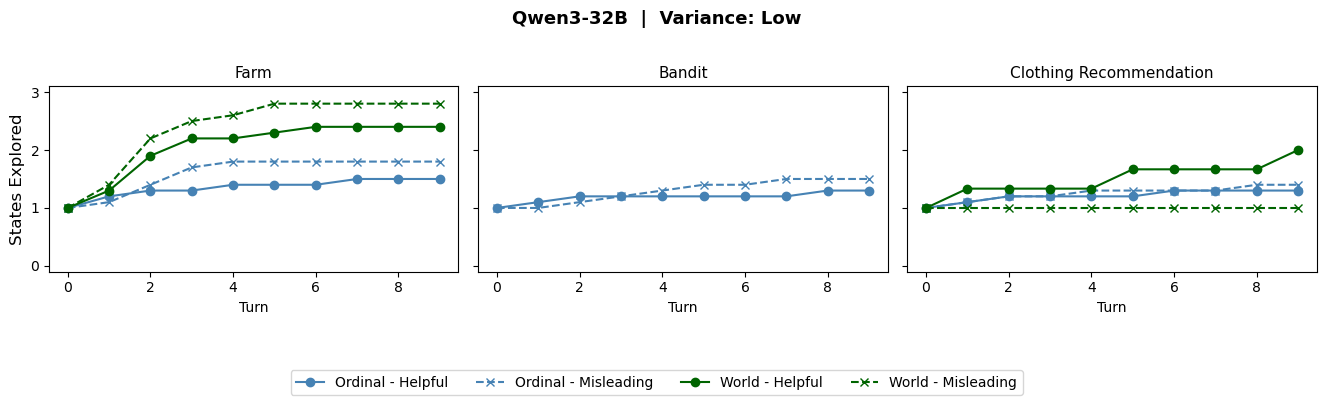

Saved: model=Qwen3-32B, metric=exploration_count, variance=Low


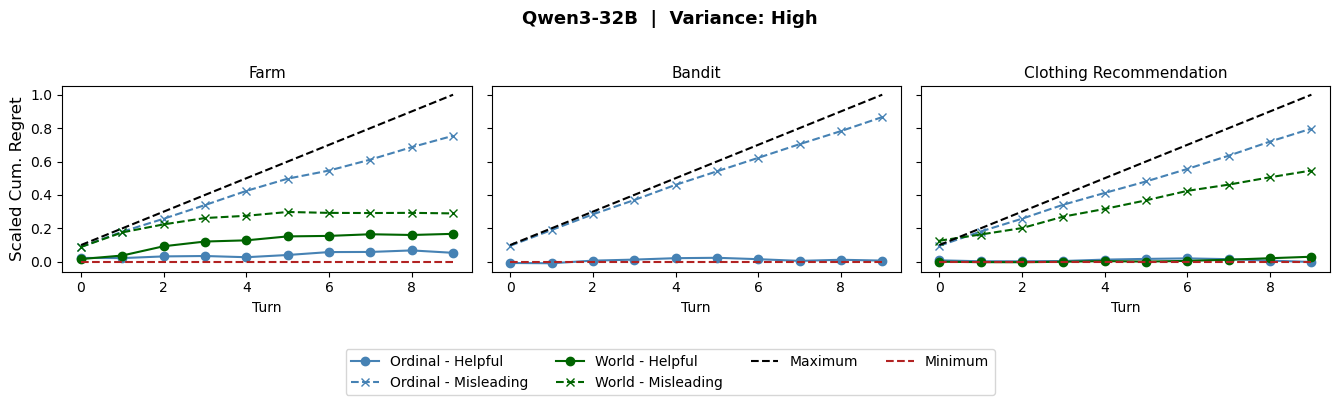

Saved: model=Qwen3-32B, metric=cum_regret, variance=High


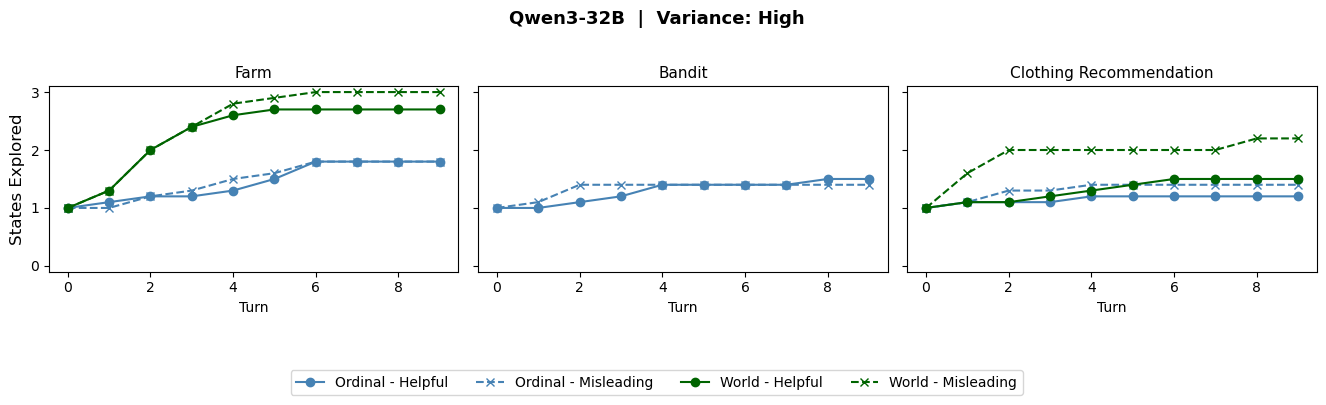

Saved: model=Qwen3-32B, metric=exploration_count, variance=High


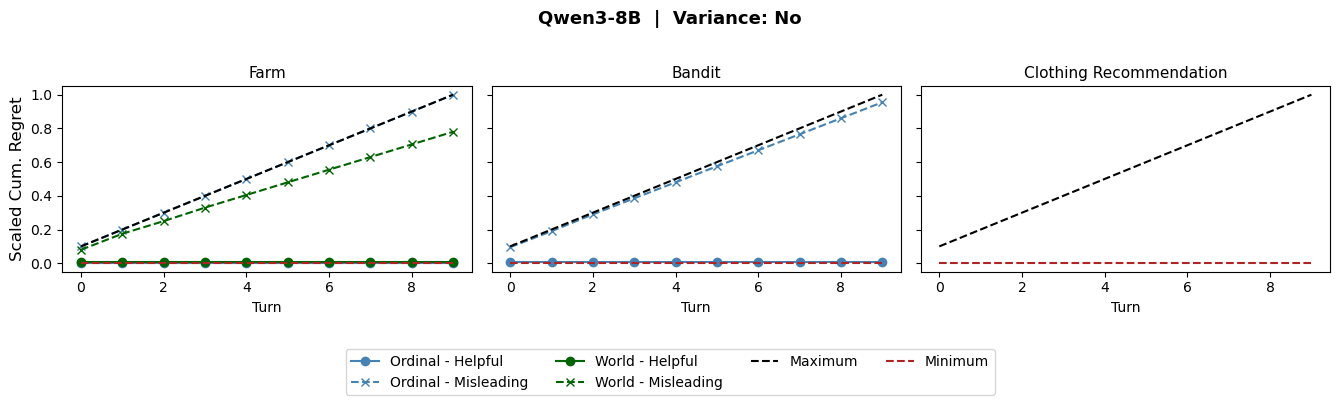

Saved: model=Qwen3-8B, metric=cum_regret, variance=No


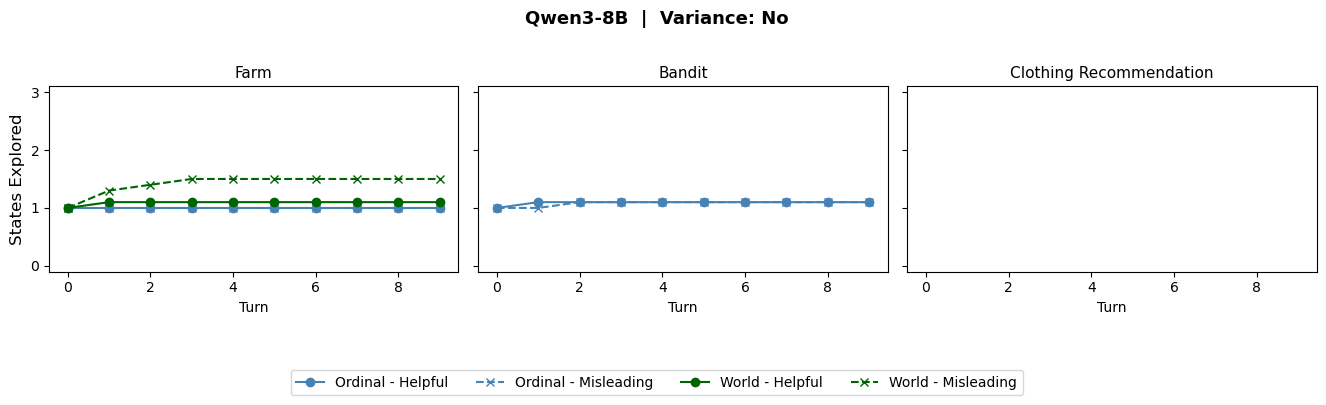

Saved: model=Qwen3-8B, metric=exploration_count, variance=No


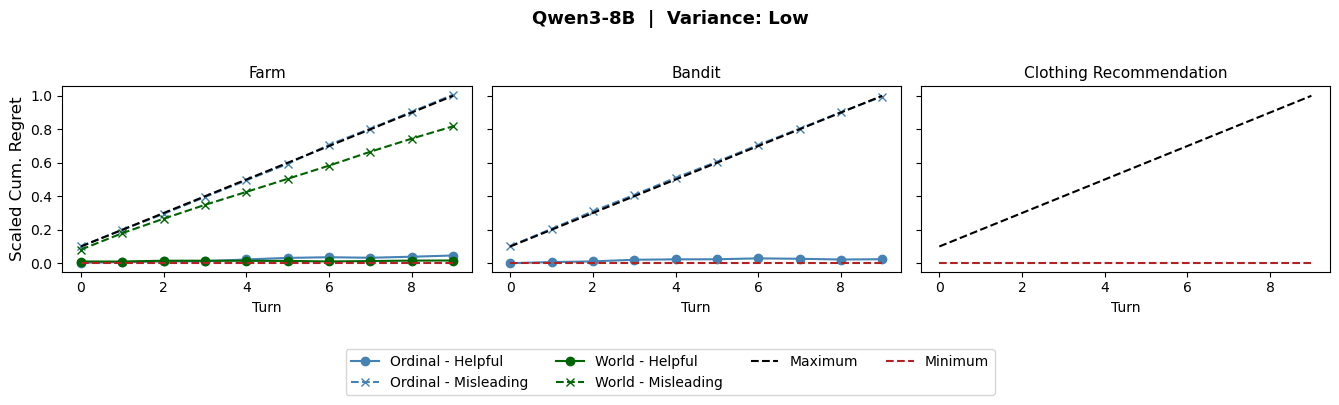

Saved: model=Qwen3-8B, metric=cum_regret, variance=Low


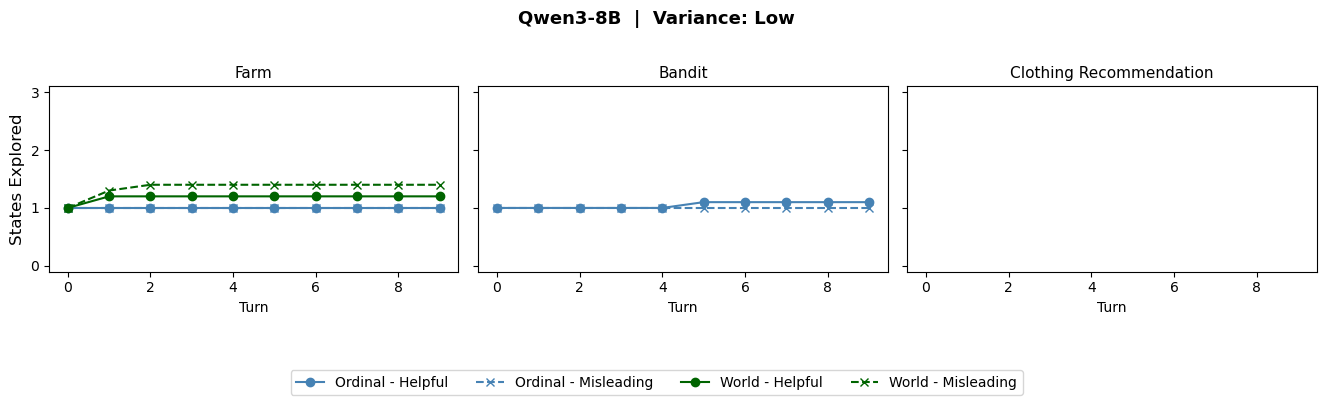

Saved: model=Qwen3-8B, metric=exploration_count, variance=Low


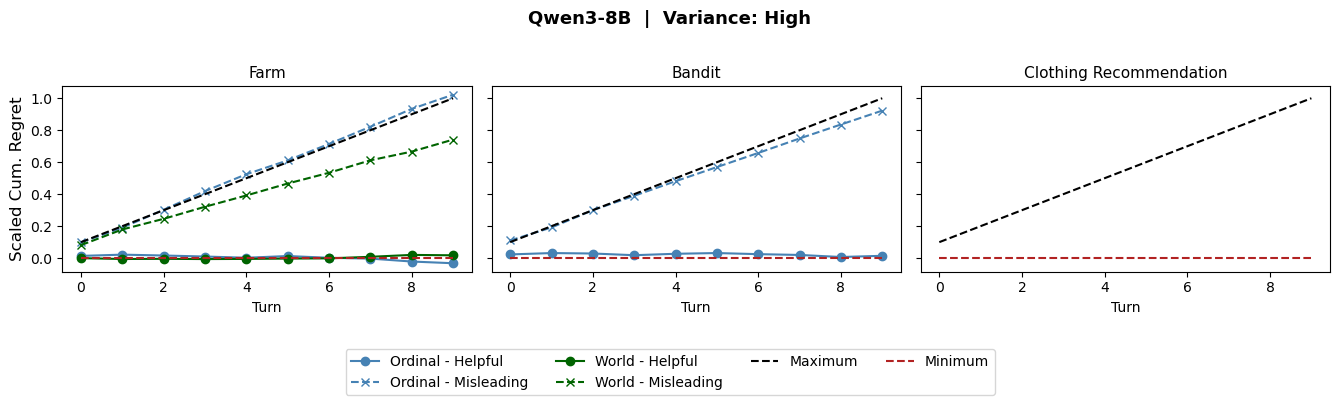

Saved: model=Qwen3-8B, metric=cum_regret, variance=High


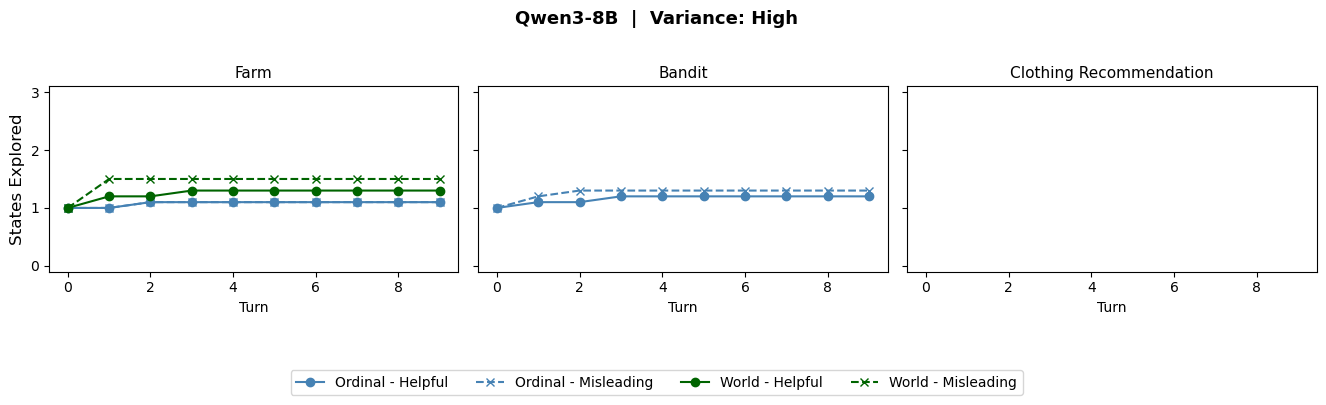

Saved: model=Qwen3-8B, metric=exploration_count, variance=High


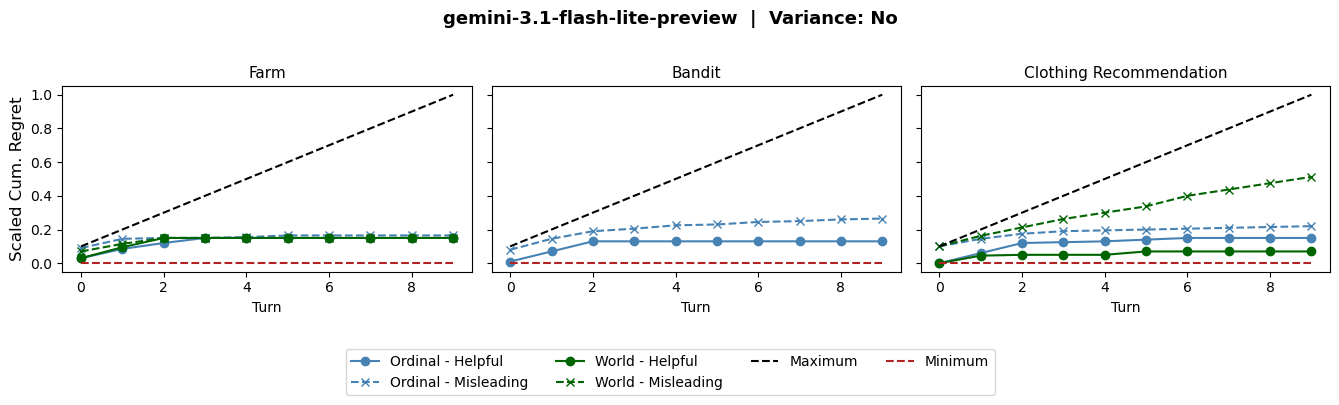

Saved: model=gemini-3.1-flash-lite-preview, metric=cum_regret, variance=No


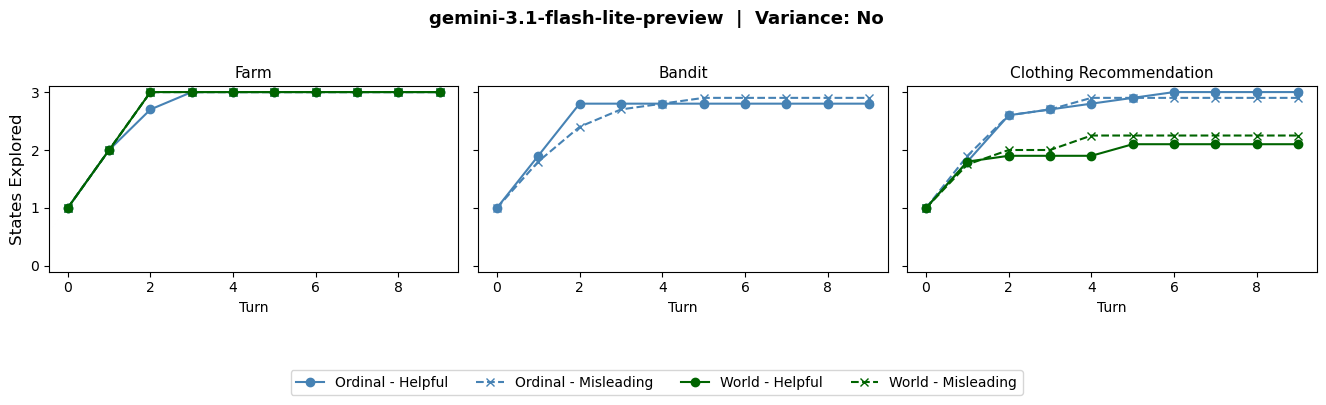

Saved: model=gemini-3.1-flash-lite-preview, metric=exploration_count, variance=No


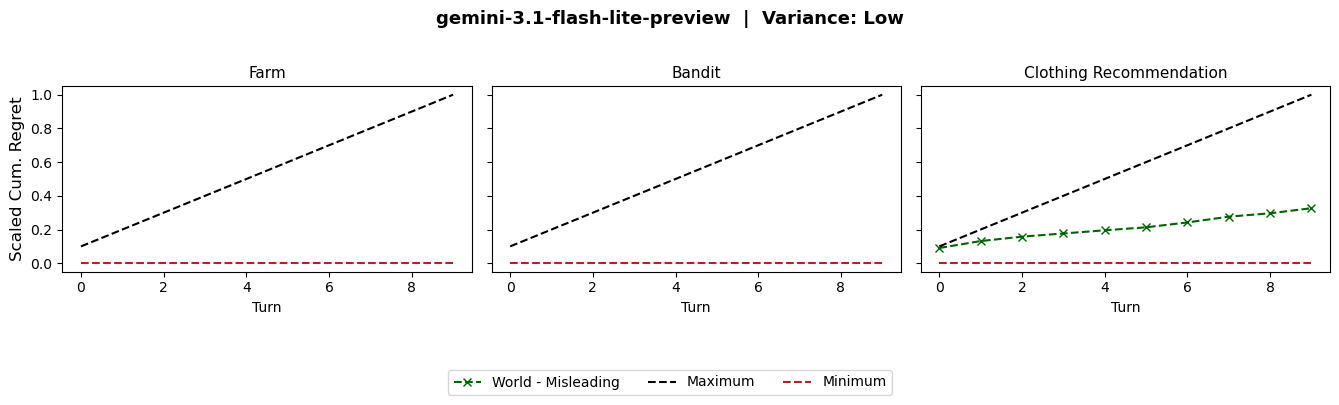

Saved: model=gemini-3.1-flash-lite-preview, metric=cum_regret, variance=Low


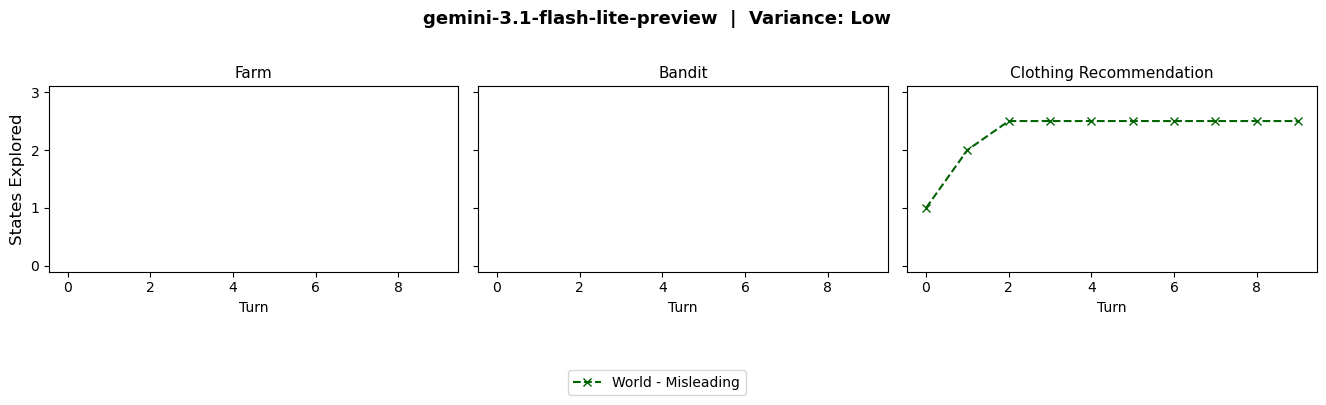

Saved: model=gemini-3.1-flash-lite-preview, metric=exploration_count, variance=Low


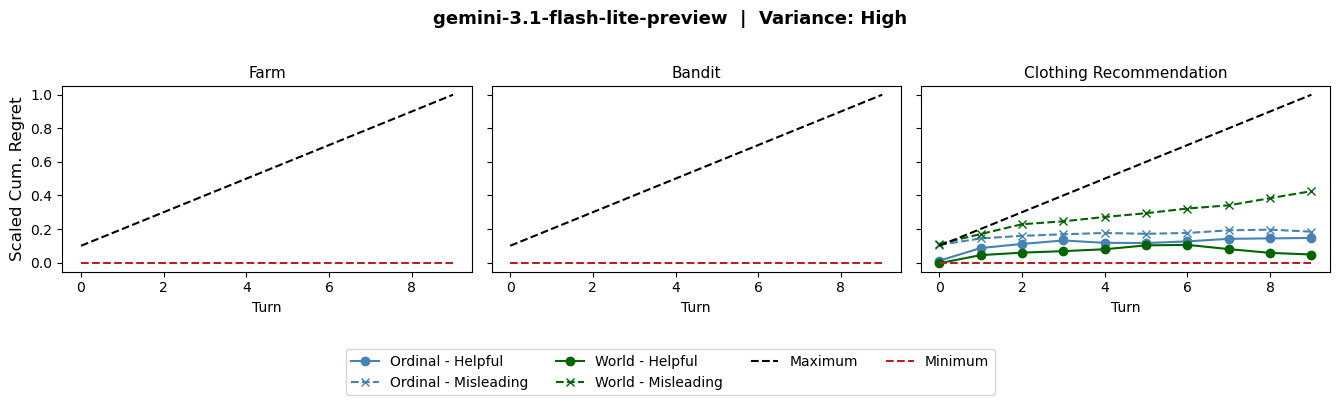

Saved: model=gemini-3.1-flash-lite-preview, metric=cum_regret, variance=High


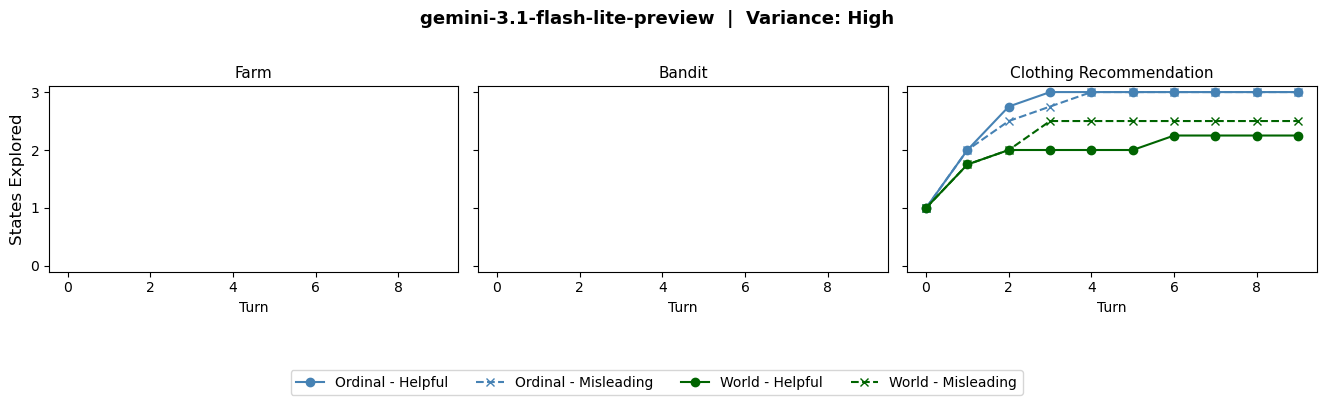

Saved: model=gemini-3.1-flash-lite-preview, metric=exploration_count, variance=High


In [9]:
all_models = sorted(results_df['model'].unique())

# Ordered domain list, restricted to those present in the data
present_domains = results_df['domain'].unique()
domains = [d for d in domain_order if d in present_domains] + \
          [d for d in present_domains if d not in domain_order]

# Extract turn numbers once from column names
turn_numbers = sorted(
    int(col.split('_')[-2])
    for col in results_df.columns
    if col.startswith('cum_regret_') and col.endswith('_mean')
)

for model in all_models:
    model_safe = re.sub(r'[^\w\-]', '_', model)

    for variance in all_variances:
        variance_safe = variance.lower()
        # if variance_safe in ['low', 'high']:
        #     continue 
        subset = results_df[
            (results_df['model']    == model)   &
            (results_df['history']  == hist)    &
            (results_df['variance'] == variance) &
            (results_df['scale']    == SCALE)
        ]
        if subset.empty:
            print(f"No data for model={model}, variance={variance}, scale={SCALE} — skipping.")
            continue

        for metric_name in metrics:
            fig, axes = plt.subplots(
                1, len(domains),
                figsize=(4.5 * len(domains), 4),
                sharex=True, sharey=True,
            )
            # Normalise to always be a list
            if len(domains) == 1:
                axes = [axes]

            fig.suptitle(f"{model}  |  Variance: {variance}", fontsize=13, fontweight='bold')

            label_to_handle = {}

            for col_idx, domain in enumerate(domains):
                ax = axes[col_idx]
                domain_subset = subset[subset['domain'] == domain]

                for nom_key in nomenclatures:
                    nom_df = domain_subset[
                        domain_subset['nomenclature'].str.contains(nom_key, na=False)
                    ]
                    if nom_df.empty:
                        continue

                    means = nom_df[[f"{metric_name}_{t}_mean" for t in turn_numbers]].values.flatten()

                    if metric_name == 'cum_regret':
                        normalizing_constant = (
                            max(rewards_per_scale[SCALE]) - min(rewards_per_scale[SCALE])
                        ) * len(means)
                        means = [x / normalizing_constant for x in means]

                    style = NOM_STYLE_CONSTANTS[nom_key]
                    try:
                        handle, = ax.plot(turn_numbers, means, **style)
                        if style['label'] not in label_to_handle:
                            label_to_handle[style['label']] = handle
                    except Exception as e:
                        print(f"ERROR: model={model} domain={domain} nom={nom_key}: {e}")

                # Min / max reference bounds for cum_regret
                if metric_name == 'cum_regret' and len(turn_numbers) > 0:
                    max_step = 1.0 / len(turn_numbers)
                    bounds = {
                        'max_val': list(np.linspace(max_step, 1.0, len(turn_numbers))),
                        'min_val': [0.0] * len(turn_numbers),
                    }
                    for bound_key, bound_vals in bounds.items():
                        handle, = ax.plot(turn_numbers, bound_vals, **STYLE_CONSTANTS[bound_key])
                        label = STYLE_CONSTANTS[bound_key]['label']
                        if label not in label_to_handle:
                            label_to_handle[label] = handle

                ax.set_xlabel("Turn")
                ax.set_title(domain, fontsize=11)

                if col_idx == 0:
                    ax.set_ylabel(metric_map[metric_name], fontsize=12)

                if metric_name == 'exploration_count':
                    ax.set_ylim(-0.1, 3.1)

            # Shared legend: nomenclatures first, then bounds
            legend_keys = nom_legend_order + ['max_val', 'min_val']
            sorted_labels, sorted_handles = [], []
            for k in legend_keys:
                lbl = (NOM_STYLE_CONSTANTS if k in NOM_STYLE_CONSTANTS else STYLE_CONSTANTS)[k]['label']
                if lbl in label_to_handle:
                    sorted_labels.append(lbl)
                    sorted_handles.append(label_to_handle[lbl])

            fig.legend(
                sorted_handles, sorted_labels,
                loc='lower center', bbox_to_anchor=(0.5, 0.0),
                ncol=4, borderaxespad=0.5, frameon=True, fontsize=10,
            )
            plt.tight_layout(rect=[0, 0.18, 1, 0.96])

            out_dir     = f"figures/{metric_name}/{model_safe}"
            out_dir_png = f"figures_png/{metric_name}/{model_safe}"
            os.makedirs(out_dir,     exist_ok=True)
            os.makedirs(out_dir_png, exist_ok=True)
            plt.savefig(f"{out_dir}/variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
            plt.savefig(f"{out_dir_png}/variance_{variance_safe}.png", dpi=300, bbox_inches='tight')

            plt.show()
            print(f"Saved: model={model}, metric={metric_name}, variance={variance}")